In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Japan Segmentation, Morphological Operations, Object Properties in Images
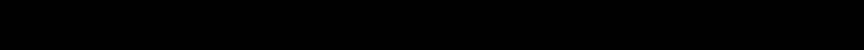
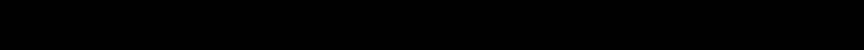
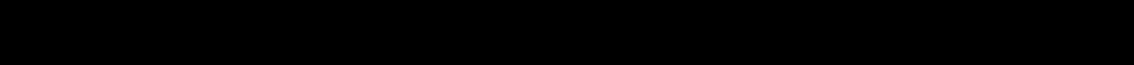

## Images Used
   - Japan Vending Machine https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.travelwithjoanne.com%2Fdiscovering-vending-machines-in-japan%2F&psig=AOvVaw1ezy_7LeI0FLlZnUYvuUYs&ust=1763563685282000&source=images&cd=vfe&opi=89978449&ved=0CBUQjRxqFwoTCMixu-z4-5ADFQAAAAAdAAAAABAE

In [2]:
def show_pair(a, b, titles=("Original", "Processed"), figsize=(10, 5), cmap='gray'):
    plt.figure(figsize=figsize)

    # left
    plt.subplot(1, 2, 1)
    if a.ndim == 2:
        plt.imshow(a, cmap=cmap)
    else:
        plt.imshow(a)
    plt.title(titles[0])
    plt.axis('off')

    # right
    plt.subplot(1, 2, 2)
    if b.ndim == 2:
        plt.imshow(b, cmap=cmap)
    else:
        plt.imshow(b)
    plt.title(titles[1])
    plt.axis('off')

    plt.show()

In [3]:
def load_rgb(path: str, dummy: bool = False, size: tuple[int, int] = (720, 1080)) -> np.ndarray:
    if os.path.exists(path) and not dummy:
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            dummy = True
        else:
            return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # dummy: colorful gradient + noise
    h, w = size
    y = np.linspace(0, 1, h)[:, None]
    x = np.linspace(0, 1, w)[None, :]
    r = x
    g = y
    b = 1 - 0.5 * (x + y)
    img = np.stack([r, g, b], axis=2)
    img += 0.05 * np.random.RandomState(42).randn(h, w, 3)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)


In [4]:
def save_rgb(path: str, img_rgb: np.ndarray):
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, bgr)

## Day 9

### Use Case (Japan)

Segment and count **drink products in Japanese vending machines** from street photos to estimate how many items are currently for sale on each machine.


#### Problem

Japanese vending machines are tightly packed with rows of cans and bottles.
For city-scale surveys or retail analysis, we often only have **photos** (e.g., from mapping services or field staff), not direct access to machine logs. Manually counting products in each image is slow and inconsistent.

We need a way to automatically **detect and separate each product slot** in the vending area so we can reliably measure how many products are being offered by each machine in a scene.


#### Why (Rationale)

- Vending machines are a major part of everyday life in Japan and an important sales channel for beverage companies.
- Knowing how many product slots are **used vs. unused** helps:
  - Evaluate how **well stocked** machines are in different locations.
  - Analyze **product variety** and how much shelf space is given to different brands or drink types.
  - Support **competitor and urban studies** using only photographic data rather than proprietary machine logs.

By segmenting individual products from images, we can turn simple street photos into structured data (counts per machine, per location, per time).


#### Practical Use Case (Insights / Data)

From each segmented vending machine image, we aim to extract:

- **Total number of product slots** visible across all machines.
- **Number of occupied slots** (products currently for sale).
- Optional: approximate grouping of products (e.g., water, tea, soda) based on color/appearance to estimate **variety**.

These measurements can then be aggregated over many images to study stocking patterns across neighborhoods or time.


#### Selected Image

We will use a photo of **three bright red Japanese vending machines** standing side by side on a street:

- Each machine shows multiple **rows and columns of drink cans and bottles** arranged in a clear grid.
- The objects of interest are the **individual drink products** behind the glass.
- The products are visually similar but **well separated**, making them suitable for segmentation and counting in the upcoming tasks.

In [5]:
VM_PATH = "Data/VendingMachine.png"
img_vm = load_rgb(VM_PATH)

save_rgb('images/vm.jpg', img_vm)

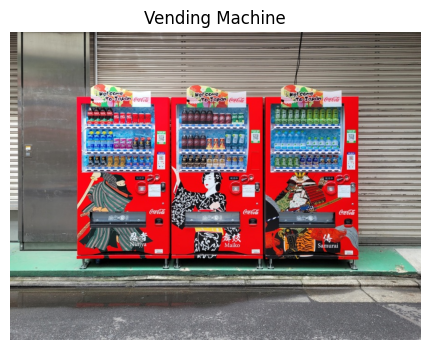

In [6]:
plt.figure(figsize=(6,4)); plt.imshow(img_vm); plt.title("Vending Machine"); plt.axis("off"); plt.show()